<a href="https://colab.research.google.com/github/gburv25-collab/L4-Data-Analysis/blob/main/Week2_Part1_Relationships_and_Associations_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Advanced Statistics  
## Part 1: Relationships and Associations

**Dataset:** `IBM_HR_Analytics.csv`  
**Tools:** Python / Google Colab  

This notebook covers:

1. Pearson and Spearman correlation  
2. Chi-square test of association  
3. Expected count checks  
4. Fisher's Exact Test as an awareness / stretch point  

The focus is not only running the tests, but also choosing methods carefully and interpreting results cautiously.

## Before You Start

Upload `IBM_HR_Analytics.csv` into the same Colab session before running the code.

In Google Colab:

1. Open the folder icon on the left.
2. Upload `IBM_HR_Analytics.csv`.
3. Run the cells in order.

Correlation should use **Variable 1** and **Variable 2** language, not IV/DV language, because correlation does not imply direction or causation.

In [ ]:
# ============================================================
# Week 2: Advanced Statistics
# Part 1: Relationships and Associations
# Dataset: IBM_HR_Analytics.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr,
    chi2_contingency,
    fisher_exact
)

## 1. Load the Dataset

In [ ]:
# Load the dataset

df = pd.read_csv("IBM_HR_Analytics.csv")

# Show the first few rows
display(df.head())

# Show dataset information
df.info()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 2. Check the Variables Used in This Notebook

In [ ]:
# Key variables for Part 1

key_variables = [
    "TotalWorkingYears",
    "MonthlyIncome",
    "Attrition",
    "OverTime"
]

# Check the columns exist
missing_columns = [col for col in key_variables if col not in df.columns]

if missing_columns:
    raise ValueError(f"The following expected columns are missing: {missing_columns}")

display(df[key_variables].head())

,TotalWorkingYears,MonthlyIncome,Attrition,OverTime
0,8,5993,Yes,Yes
1,10,5130,No,No
2,7,2090,Yes,Yes
3,8,2909,No,Yes
4,6,3468,No,No


In [ ]:
# Check data types and missing values

print("Data types:")
display(df[key_variables].dtypes)

print("\nMissing values:")
display(df[key_variables].isna().sum())

Data types:


,0
TotalWorkingYears,int64
MonthlyIncome,int64
Attrition,object
OverTime,object



Missing values:


,0
TotalWorkingYears,0
MonthlyIncome,0
Attrition,0
OverTime,0


# Practical 1: Correlation  
## Is TotalWorkingYears associated with MonthlyIncome?

For correlation, use:

| Variable role | Variable | Type |
|---|---|---|
| Variable 1 | TotalWorkingYears | Numerical |
| Variable 2 | MonthlyIncome | Numerical |

Correlation explores association. It does **not** prove that one variable causes the other.

## 3. Select the Variables

In [ ]:
# Select the two variables and remove missing rows for this analysis

correlation_data = df[["TotalWorkingYears", "MonthlyIncome"]].dropna()

display(correlation_data.head())
print("Number of rows used:", len(correlation_data))

,TotalWorkingYears,MonthlyIncome
0,8,5993
1,10,5130
2,7,2090
3,8,2909
4,6,3468


Number of rows used: 1470


## 4. Descriptive Statistics and Skewness

In [ ]:
# Summary statistics

display(correlation_data.describe())

,TotalWorkingYears,MonthlyIncome
count,1470.000000,1470.000000
mean,11.279592,6502.931293
std,7.780782,4707.956783
min,0.000000,1009.000000
25%,6.000000,2911.000000
50%,10.000000,4919.000000
75%,15.000000,8379.000000
max,40.000000,19999.000000


In [ ]:
# Skewness check
# Larger positive or negative values suggest stronger skewness

display(correlation_data.skew())

,0
TotalWorkingYears,1.117172
MonthlyIncome,1.369817


## 5. Visual Checks

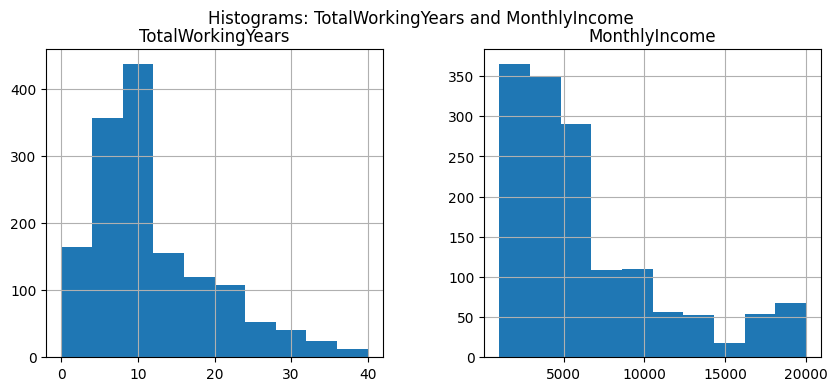

In [ ]:
# Histograms

correlation_data.hist(figsize=(10, 4))
plt.suptitle("Histograms: TotalWorkingYears and MonthlyIncome")
plt.show()

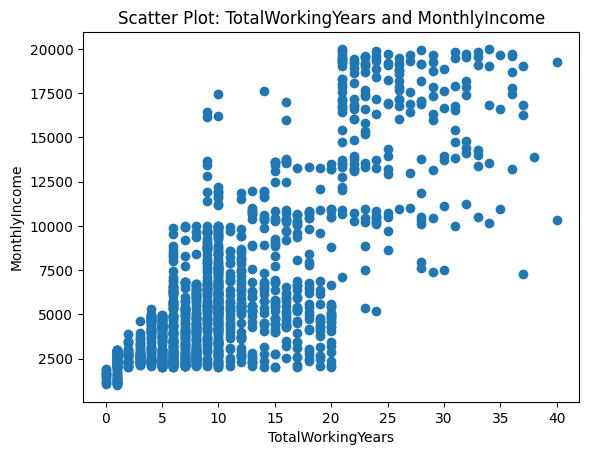

In [ ]:
# Scatter plot

plt.scatter(
    correlation_data["TotalWorkingYears"],
    correlation_data["MonthlyIncome"]
)

plt.xlabel("TotalWorkingYears")
plt.ylabel("MonthlyIncome")
plt.title("Scatter Plot: TotalWorkingYears and MonthlyIncome")
plt.show()

## 6. Choose Pearson or Spearman

Use **Pearson** when:

- both variables are numerical
- the relationship is approximately linear
- there are no major outliers
- assumptions are reasonably met

Use **Spearman** when:

- variables are ordinal, ranked, skewed, or affected by outliers
- the relationship is monotonic rather than clearly linear
- a non-parametric approach is safer

## 7. Run Pearson and Spearman Correlation

In [ ]:
# Pearson correlation

pearson_r, pearson_p = pearsonr(
    correlation_data["TotalWorkingYears"],
    correlation_data["MonthlyIncome"]
)

print("Pearson correlation coefficient:", pearson_r)
print("Pearson p-value:", pearson_p)

Pearson correlation coefficient: 0.7728932462543562
Pearson p-value: 2.7293476156909726e-292


In [ ]:
# Spearman correlation

spearman_rho, spearman_p = spearmanr(
    correlation_data["TotalWorkingYears"],
    correlation_data["MonthlyIncome"]
)

print("Spearman correlation coefficient:", spearman_rho)
print("Spearman p-value:", spearman_p)

Spearman correlation coefficient: 0.7100243140565019
Spearman p-value: 7.311731893248116e-226


In [ ]:
# Present results in a table

correlation_results = pd.DataFrame({
    "Test": ["Pearson correlation", "Spearman correlation"],
    "Correlation coefficient": [pearson_r, spearman_rho],
    "p-value": [pearson_p, spearman_p]
})

display(correlation_results)

,Test,Correlation coefficient,p-value
0,Pearson correlation,0.772893,2.729348e-292
1,Spearman correlation,0.710024,7.311732e-226


## 8. Interpret the Correlation Results

In [ ]:
def interpret_correlation(value):
    """Return a simple teaching-level interpretation of correlation strength and direction."""
    abs_value = abs(value)

    if abs_value < 0.20:
        strength = "very weak"
    elif abs_value < 0.40:
        strength = "weak"
    elif abs_value < 0.60:
        strength = "moderate"
    elif abs_value < 0.80:
        strength = "strong"
    else:
        strength = "very strong"

    direction = "positive" if value > 0 else "negative"

    return f"{strength} {direction} relationship"


def interpret_p_value_association(p):
    """Return a cautious interpretation of a p-value for association tests."""
    if p < 0.05:
        return "evidence of a statistically significant association in the sample"
    else:
        return "insufficient evidence of a statistically significant association in the sample"


print("Pearson interpretation:")
print(interpret_correlation(pearson_r))
print(interpret_p_value_association(pearson_p))

print("\nSpearman interpretation:")
print(interpret_correlation(spearman_rho))
print(interpret_p_value_association(spearman_p))

Pearson interpretation:
strong positive relationship
evidence of a statistically significant association in the sample

Spearman interpretation:
strong positive relationship
evidence of a statistically significant association in the sample


In [ ]:
# Example reporting sentence
# Change chosen_test, chosen_coefficient and chosen_p if you decide Pearson is more appropriate.

chosen_test = "Spearman correlation"
chosen_coefficient = spearman_rho
chosen_p = spearman_p

print(
    f"A {chosen_test} was used to examine the association between "
    f"TotalWorkingYears and MonthlyIncome. The correlation coefficient was "
    f"{chosen_coefficient:.3f}, suggesting a {interpret_correlation(chosen_coefficient)}. "
    f"The p-value was {chosen_p:.5f}, which suggests {interpret_p_value_association(chosen_p)}. "
    f"This does not prove causation."
)

A Spearman correlation was used to examine the association between TotalWorkingYears and MonthlyIncome. The correlation coefficient was 0.710, suggesting a strong positive relationship. The p-value was 0.00000, which suggests evidence of a statistically significant association in the sample. This does not prove causation.


# Practical 2: Chi-Square Test of Association  
## Is Attrition associated with OverTime?

Chi-square is used when:

- both variables are categorical
- the aim is to test whether they are associated
- categories are mutually exclusive
- observations are independent
- expected counts are sufficiently large
- the sample is random or reasonably representative if making wider claims

## 9. Create a Contingency Table

In [ ]:
# Create a contingency table

contingency_table = pd.crosstab(df["Attrition"], df["OverTime"])

display(contingency_table)

OverTime,No,Yes
Attrition,,
No,944,289
Yes,110,127


## 10. Run Chi-Square Test

In [ ]:
chi2, chi2_p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", chi2_p)
print("Degrees of freedom:", dof)

Chi-square statistic: 87.56429365828768
p-value: 8.15842372153832e-21
Degrees of freedom: 1


In [ ]:
# Show expected counts

expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

display(expected_table)

OverTime,No,Yes
Attrition,,
No,884.069388,348.930612
Yes,169.930612,67.069388


## 11. Check Expected Counts

In [ ]:
# Check whether any expected counts are below 5

minimum_expected = expected_table.min().min()
number_below_5 = (expected_table < 5).sum().sum()

print("Minimum expected count:", minimum_expected)
print("Number of expected counts below 5:", number_below_5)

if number_below_5 == 0:
    print("Expected counts appear acceptable for chi-square.")
else:
    print("Some expected counts are below 5. Chi-square may be less reliable.")

Minimum expected count: 67.06938775510204
Number of expected counts below 5: 0
Expected counts appear acceptable for chi-square.


## 12. Fisher's Exact Test Awareness Point

Fisher's Exact Test may be considered when:

- there are two categorical variables
- the table is small, especially 2x2
- expected counts are too low for chi-square to be reliable

For this session, Fisher's Exact Test is included as an awareness / stretch point. Chi-square remains the main method.

In [ ]:
# Fisher's Exact Test works directly on a 2x2 table.

if contingency_table.shape == (2, 2):
    odds_ratio, fisher_p = fisher_exact(contingency_table)

    print("Fisher's Exact Test")
    print("Odds ratio:", odds_ratio)
    print("p-value:", fisher_p)
else:
    print("Fisher's Exact Test is usually demonstrated with a 2x2 table.")

Fisher's Exact Test
Odds ratio: 3.7712488203837684
p-value: 2.3614136895902993e-19


## 13. Interpret Chi-Square

In [ ]:
def interpret_chi_square_p_value(p):
    if p < 0.05:
        return "evidence of an association in the sample"
    else:
        return "insufficient evidence of an association in the sample"


print(
    f"A chi-square test was used to examine whether Attrition was associated "
    f"with OverTime. The chi-square statistic was {chi2:.3f}, with {dof} degrees "
    f"of freedom. The p-value was {chi2_p:.5f}, suggesting "
    f"{interpret_chi_square_p_value(chi2_p)}. This does not prove that "
    f"OverTime causes Attrition."
)

A chi-square test was used to examine whether Attrition was associated with OverTime. The chi-square statistic was 87.564, with 1 degrees of freedom. The p-value was 0.00000, suggesting evidence of an association in the sample. This does not prove that OverTime causes Attrition.


## 14. Reflection Questions

Answer these in your worksheet:

1. Why is correlation not described using IV and DV language?
2. Which correlation result would you report and why?
3. Why is chi-square appropriate for Attrition and OverTime?
4. Were the expected counts acceptable?
5. Why should Fisher's Exact Test only be treated as an awareness point here?
6. What cautious business conclusion could you write from the chi-square result?